<a href="https://colab.research.google.com/github/ajaypadida/OIBSIP-DATASCIENCE/blob/main/Car_Price_Prediction_with_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# 1) Install dependencies
!pip install --quiet kagglehub pandas scikit-learn matplotlib seaborn

In [16]:
# 2) Imports
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
# 3) Download the dataset
raw_path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")
print("raw_path =", raw_path)

raw_path = /kaggle/input/car-price-predictionused-cars


In [18]:
# 4) Extract if zip, else use as folder
if os.path.isdir(raw_path):
    data_dir = raw_path
else:
    data_dir = "/content/car_price_data"
    os.makedirs(data_dir, exist_ok=True)
    with ZipFile(raw_path, 'r') as z:
        z.extractall(data_dir)
print("Data directory:", data_dir)
print("Contents:", os.listdir(data_dir))


Data directory: /kaggle/input/car-price-predictionused-cars
Contents: ['car data.csv']


In [19]:
# 5) Load the first CSV
csv_files = [f for f in os.listdir(data_dir) if f.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV found in " + data_dir)
df = pd.read_csv(os.path.join(data_dir, csv_files[0]))
print("Loaded:", csv_files[0])
df.head()

Loaded: car data.csv


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [20]:
# 6) Clean column names
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [21]:
# 7) Identify target (price) column
target_col = next((c for c in df.columns if "price" in c.lower()), None)
if target_col is None:
    raise KeyError("No price column found")
print("Using target:", target_col)

Using target: Selling_Price


In [22]:
# 8) Drop rows without price, split X/y
df = df[df[target_col].notna()]
X = df.drop(columns=[target_col])
y = df[target_col]

In [23]:
# 9) Fill missing values
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include=['object','category']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

In [24]:
# 10) One-hot encode categoricals
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (301, 105)


In [25]:
# 11) Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# 12) Train RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [27]:
# 13) Predict & Evaluate
y_pred = model.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²:   {r2:.3f}")


Test RMSE: 0.87
Test R²:   0.967


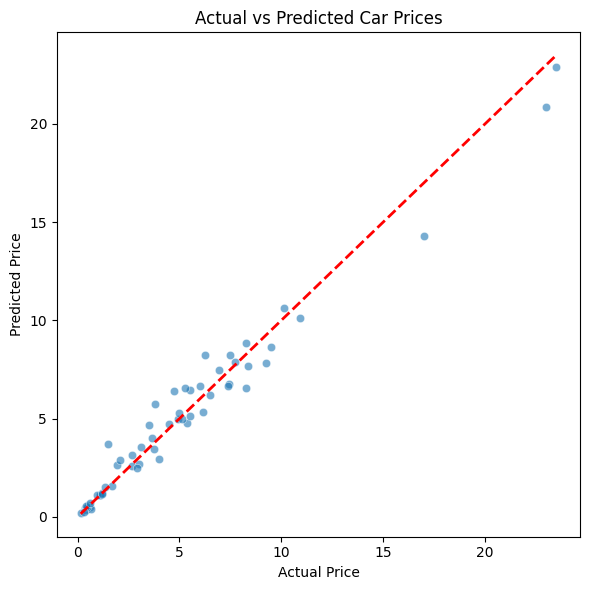

In [28]:
# 14) Plot Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.tight_layout()
plt.show()

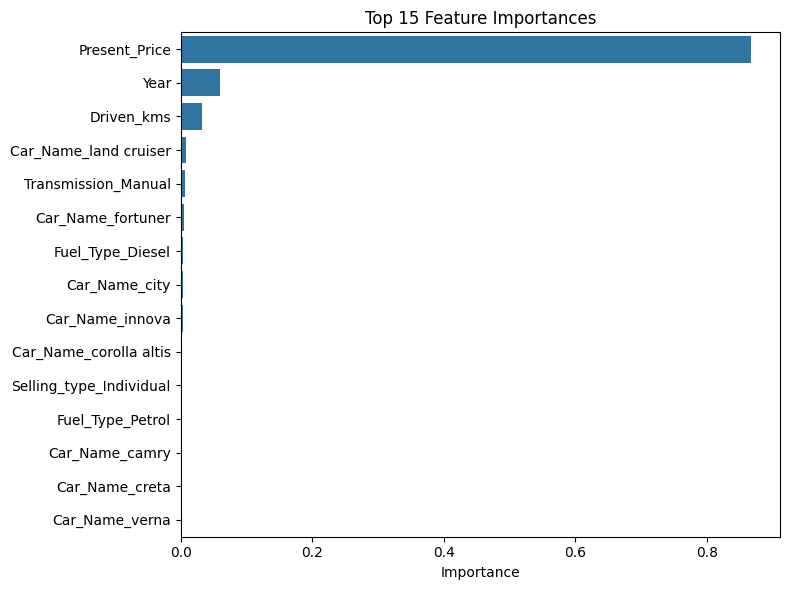

In [29]:
# 15) Top-15 Feature Importances
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
top15 = feat_imp.nlargest(15)
plt.figure(figsize=(8,6))
sns.barplot(x=top15.values, y=top15.index)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance"); plt.ylabel("")
plt.tight_layout()
plt.show()